<a href="https://colab.research.google.com/github/jeffheaton/dynaface/blob/main/dynaface-lib-python/examples/dynaface_intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dynaface
You can install Dynaface with pip.

In [2]:
#!pip install --upgrade https://s3.us-east-1.amazonaws.com/data.heatonresearch.com/library/dynaface-2.0.0-py3-none-any.whl
!pip install dynaface==2.0.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 12.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.13.0.92
    Uninstalling opencv-python-4.13.0.92:
      Successfully uninstalled opencv-python-4.13.0.92


In [3]:
import dynaface
print(f"Dynaface-lib version: {dynaface.__version__}")

Dynaface-lib version: 2.0.0


The following method is used to scale OpenCV images for display.

In [4]:
%matplotlib inline

import cv2

def scale_image(image, max_width=256):
    """
    Resize an image to a maximum width while preserving aspect ratio.

    Parameters:
        image (np.ndarray): Input image (BGR, as from OpenCV)
        max_width (int): Maximum width in pixels

    Returns:
        np.ndarray: Resized image (or original if no resize needed)
    """
    h, w = image.shape[:2]

    if w <= max_width:
        return image.copy()

    scale = max_width / w
    new_size = (int(w * scale), int(h * scale))

    return cv2.resize(image, new_size, interpolation=cv2.INTER_AREA)

You may have to restart your Colab environment due to the install.

Dynaface uses Python logging, if you would like to see it, set the log level to what is desired.

In [5]:
import logging
import sys

log_level = logging.INFO

# Remove any existing handlers
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

# Set up a new handler that logs to the console at DEBUG level
console_handler = logging.StreamHandler(sys.stdout)
console_handler.setLevel(log_level)
formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
console_handler.setFormatter(formatter)

# Add the handler to the root logger
logging.root.setLevel(log_level)
logging.root.addHandler(console_handler)

Dynaface makes use of several models, which must be downloaded or embedded into your application. The following code downloads the models.

In [6]:
from dynaface import facial, measures, models
import dynaface

print("...Downloading models... please wait...")
# Choose device
device = models.detect_device()
print(f"Detected device: {device}")

# Download and init models
dynaface.util.VERIFY_CERTS = True # Prevent warnings, remove if downloads fail
path = models.download_models()
models.init_models(path, device)

...Downloading models... please wait...
Detected device: cpu
2026-07-12 19:43:03,078 - INFO - Downloading DynaFace model files from https://data.heatonresearch.com/dynaface/model/2/dynaface_models.zip...


Load an image and convert to CV2.

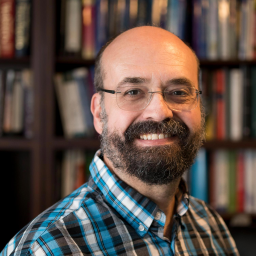

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests
from google.colab.patches import cv2_imshow
from io import BytesIO

# Provide the image URL
image_url = "https://www.heatonresearch.com/images/jeff/about-jeff-heaton-2020.jpg"  # Replace with the actual image URL

# Download the image
response = requests.get(image_url)
image_array = np.array(bytearray(response.content), dtype=np.uint8)

# Decode the image using OpenCV
image = cv2.imdecode(image_array, cv2.IMREAD_COLOR)

# display the image
cv2_imshow(scale_image(image))

Analyze the image and print out key measures.

In [ ]:
from dynaface.measures_frontal import AnalyzeLandmarks

# Get all measures, but remove the low-level AnalyzeLandmarks that return all x,y for all 97 landmarks.
all_measures = [
    m for m in measures.all_measures()
    if not isinstance(m, AnalyzeLandmarks)
]

face = facial.AnalyzeFace(measures=all_measures)
# dynaface works in RGB internally; OpenCV decoded this image as BGR, so convert
# before handing it to load_image (passing BGR can cause face detection to fail).
face.load_image(cv2.cvtColor(image, cv2.COLOR_BGR2RGB), crop=True)
face.analyze()

Display the images with measures marked.

In [ ]:
# render_img is RGB (dynaface's convention); cv2_imshow expects BGR, so convert for display.
cv2_imshow(scale_image(cv2.cvtColor(face.render_img, cv2.COLOR_RGB2BGR)))